# Kaplan-Meier survival analysis with lifelines

This notebook is a reproducible, educational example using the Waltons dataset bundled with `lifelines`. It is not an analysis of the interview-case customer data.

A Kaplan-Meier (KM) curve estimates the probability of remaining event-free beyond each time point. Here, the event is death, time starts at birth, and duration is measured in days. A fly that is still alive when observation ends (or is accidentally killed or escapes before its natural death) is right-censored: we know it survived at least until its last observed time, but not when its natural death occurred. The estimator uses that partial follow-up without treating censoring as a death.

## 1. Load the documented example data

`lifelines.datasets.load_waltons()` provides 163 Drosophila records. Its fields are `T` (days survived), `E` (1 when death was observed; 0 when right-censored), and `group` (genotype: `control` or `miR-137`). The dataset and its censoring description are documented in the [lifelines datasets reference](https://lifelines.readthedocs.io/en/latest/lifelines.datasets.html).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.datasets import load_waltons
from lifelines.plotting import add_at_risk_counts

# Resolve paths whether the notebook is launched from the repository root or its own folder.
project_name = "20260929_rbouch85_kaplan_meier_example"
working_dir = Path.cwd().resolve()
project_dir = working_dir if working_dir.name == project_name else working_dir / "projects" / project_name
repo_root = project_dir.parents[1]
sys.path.insert(0, str(repo_root / "shared-tools" / "visualization"))
from save_and_show import save_and_show_mpl

figure_dir = project_dir / "outputs" / "figures"
data = load_waltons()
data.head()

,T,E,group
0,6.0,1,miR-137
1,13.0,1,miR-137
2,13.0,1,miR-137
3,13.0,1,miR-137
4,19.0,1,miR-137


## 2. Check the event and follow-up data

Before fitting, confirm durations are present and nonnegative, event indicators are binary, and each group uses the same event definition and time scale. The counts below make censoring visible rather than silently treating it as an event.

In [2]:
analysis = data[["T", "E", "group"]].dropna().copy()
analysis = analysis.rename(columns={"T": "duration_days", "E": "event_observed"})

assert len(analysis) == len(data), "Unexpected missing analysis values."
assert (analysis["duration_days"] >= 0).all(), "Durations must be nonnegative."
assert set(analysis["event_observed"].unique()).issubset({0, 1}), "Events must be coded 0/1."
assert analysis["group"].nunique() > 1, "Expected multiple genotypes for grouped curves."

group_summary = (
    analysis.groupby("group", observed=True)
    .agg(
        flies=("duration_days", "size"),
        observed_deaths=("event_observed", "sum"),
        right_censored=("event_observed", lambda values: (values == 0).sum()),
        earliest_followup_days=("duration_days", "min"),
        latest_followup_days=("duration_days", "max"),
    )
)
group_summary

,flies,observed_deaths,right_censored,earliest_followup_days,latest_followup_days
group,,,,,
control,129,122,7,7.0,75.0
miR-137,34,34,0,6.0,62.0


## 3. Fit the overall Kaplan-Meier estimate

At each observed death time, the estimated event-free probability steps down according to deaths among flies still at risk. Censored flies contribute to the risk set up to their last observed time but do not create a step down. The default confidence interval from `lifelines` is shown alongside the estimate.

In [3]:
overall_kmf = KaplanMeierFitter(label="All genotypes")
overall_kmf.fit(
    durations=analysis["duration_days"],
    event_observed=analysis["event_observed"],
    label="All genotypes",
)

survival_and_ci = overall_kmf.survival_function_.join(overall_kmf.confidence_interval_)
survival_and_ci.head(10)

,All genotypes,All genotypes_lower_0.95,All genotypes_upper_0.95
timeline,,,
0.0,1.000000,1.000000,1.000000
6.0,0.993865,0.957254,0.999134
7.0,0.987730,0.951834,0.996917
9.0,0.969210,0.927613,0.987068
13.0,0.950690,0.903821,0.975031
15.0,0.938344,0.888437,0.966342
17.0,0.932170,0.880865,0.961853
19.0,0.913650,0.858549,0.947930
22.0,0.888957,0.829547,0.928543


In [4]:
overall_median = overall_kmf.median_survival_time_
if np.isinf(overall_median):
    print("Overall median survival was not reached within the observed follow-up window.")
else:
    print(f"Overall median survival: {overall_median:.0f} days")

print("Event table (first observed times):")
display(overall_kmf.event_table.head(8))
print("Event table (last observed times):")
display(overall_kmf.event_table.tail(8))

Overall median survival: 56 days
Event table (first observed times):


,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,163,163
6.0,1,1,0,0,163
7.0,2,1,1,0,162
9.0,3,3,0,0,160
13.0,3,3,0,0,157
15.0,2,2,0,0,154
17.0,1,1,0,0,152
19.0,3,3,0,0,151


Event table (last observed times):


,removed,observed,censored,entrance,at_risk
event_at,,,,,
60.0,16,15,1,0,65
61.0,11,9,2,0,49
62.0,2,2,0,0,38
63.0,9,9,0,0,36
66.0,3,3,0,0,27
68.0,10,9,1,0,24
69.0,13,12,1,0,14
75.0,1,1,0,0,1


The event table separates the number at risk, observed deaths, and censored observations at each time. In this small example the raw table contains many time points, so both its beginning and end are shown; the plotted risk table below summarizes follow-up support at selected times.

## 4. Compare descriptive curves by genotype

The groups share the same time origin, death definition, duration units, and source dataset, so their KM curves can be displayed on a common scale. These curves are descriptive, not a causal or adjusted comparison. Confidence bands show uncertainty; censor marks indicate observed censoring times; the at-risk row reports how many flies remain under observation at the tick marks.

In [5]:
group_fitters = {}
for group_name, group_data in analysis.groupby("group", observed=True, sort=True):
    fitter = KaplanMeierFitter(label=group_name)
    fitter.fit(
        durations=group_data["duration_days"],
        event_observed=group_data["event_observed"],
        label=group_name,
    )
    group_fitters[group_name] = fitter

median_rows = []
for group_name, fitter in group_fitters.items():
    median = fitter.median_survival_time_
    median_rows.append(
        {
            "group": group_name,
            "median_survival_days": "not reached" if np.isinf(median) else round(median, 1),
        }
    )
median_table = pd.DataFrame(median_rows).set_index("group")
display(median_table)

median_by_group = {group: fitter.median_survival_time_ for group, fitter in group_fitters.items()}
size_by_group = analysis.groupby("group", observed=True).size()
print(
    "Descriptively, median survival was "
    f"{median_by_group['control']:.0f} days for control (n={size_by_group['control']}) "
    f"and {median_by_group['miR-137']:.0f} days for miR-137 (n={size_by_group['miR-137']}). "
    "These unadjusted estimates are not causal; late follow-up is uncertain where few flies remain at risk."
)

,median_survival_days
group,
control,58.0
miR-137,26.0


Descriptively, median survival was 58 days for control (n=129) and 26 days for miR-137 (n=34). These unadjusted estimates are not causal; late follow-up is uncertain where few flies remain at risk.


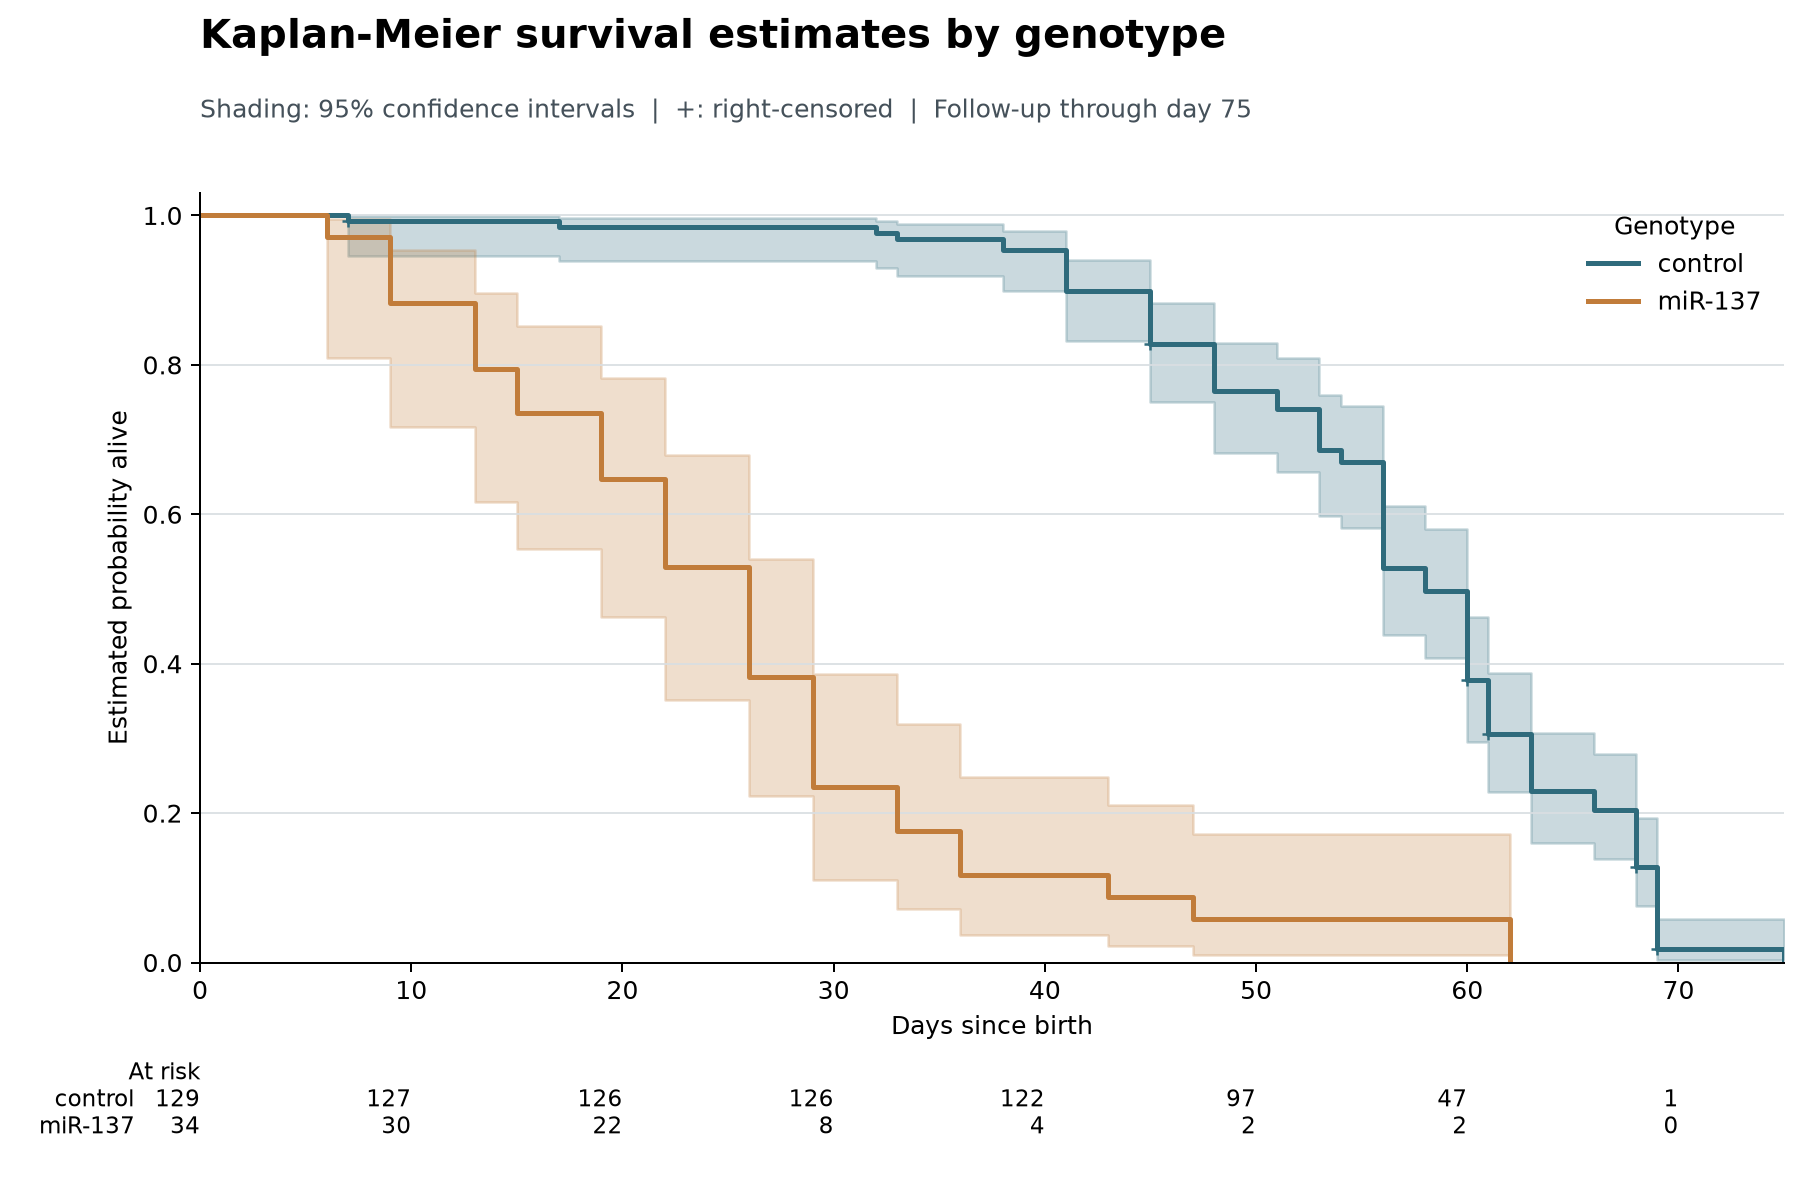

Saved figure to projects\20260929_rbouch85_kaplan_meier_example\outputs\figures\waltons_kaplan_meier.png


In [6]:
# Matplotlib is used because lifelines' KM and at-risk-count plotting helpers return Matplotlib axes.
colors = {"control": "#2F6B7C", "miR-137": "#C17C3A"}
fig, ax = plt.subplots(figsize=(10, 7.5))
for group_name, fitter in group_fitters.items():
    fitter.plot_survival_function(
        ax=ax,
        ci_show=True,
        color=colors.get(group_name),
        show_censors=True,
        censor_styles={"marker": "+", "ms": 5},
        linewidth=2,
    )

max_followup = int(analysis["duration_days"].max())
ax.set_xlabel("Days since birth")
ax.set_ylabel("Estimated probability alive")
ax.set_xlim(0, max_followup)
ax.set_ylim(0, 1.03)
ax.set_xticks(np.arange(0, max_followup + 1, 10))
ax.grid(axis="y", color="#D9DEE2", linewidth=0.7)
ax.grid(axis="x", visible=False)
ax.legend(title="Genotype", frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
add_at_risk_counts(
    *group_fitters.values(),
    ax=ax,
    rows_to_show=["At risk"],
    labels=list(group_fitters.keys()),
    fontsize=9,
)
fig.suptitle(
    "Kaplan-Meier survival estimates by genotype",
    x=0.10,
    y=0.98,
    ha="left",
    fontsize=16,
    fontweight="bold",
)
fig.text(
    0.10,
    0.92,
    "Shading: 95% confidence intervals  |  +: right-censored  |  Follow-up through day 75",
    ha="left",
    va="top",
    fontsize=10,
    color="#45515A",
)
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.28, top=0.85)
figure_path = save_and_show_mpl(
    fig,
    "waltons_kaplan_meier",
    output_dir=figure_dir,
    dpi=180,
)
print(f"Saved figure to {figure_path.relative_to(repo_root)}")

## 5. How to interpret this example

A higher curve means a higher estimated probability of being alive beyond a given day. The estimate accounts for flies whose natural death was not observed by their last follow-up. The shaded bands are confidence intervals, and the risk table helps show when the remaining sample becomes small. A median is the time when the estimated survival probability first reaches 0.5; if it is not reached, report it as not reached in the observed window rather than interpreting it as zero risk.

### Assumptions and limitations

- The event, time origin, units, and group labels must be defined consistently; this example uses death, birth, days, and genotype.
- Kaplan-Meier estimation assumes censoring is sufficiently non-informative: conditional on the analysis, censored flies should not have systematically different unobserved survival prospects than those remaining under observation. Accidental loss may challenge this assumption.
- KM is unadjusted for other characteristics. The group curves are descriptive and do not establish that genotype caused a difference; no hypothesis test or causal model is fit here.
- Estimates near the end of follow-up are less certain when few flies remain at risk. Do not read a flat tail as evidence of no further deaths.
- These findings are limited to this example dataset and observed follow-up; they are not claims about customer retention or the repository's case data.

For further details, see the [`KaplanMeierFitter` API documentation](https://lifelines.readthedocs.io/en/latest/fitters/univariate/KaplanMeierFitter.html) and the project [Kaplan-Meier survival skill](../../.github/skills/kaplan-meier-survival/SKILL.md).